**Práctica 2. Parte 2.**
**Por Manuela Hernández y Juan Cubides**


**Acercamiento a la base de datos de arritmias cardiacas y comparación estadística** 

**Actividad**

**1.** Exploración y descripción de la base de datos.
Realice una exploración general de la base de datos proporcionada. Identifique y describa:
  •Número total de registros y sujetos.
•Tipos de arritmias o clases disponibles.
•Número de sujetos o registros pertenecientes a cada grupo.
•Número de canales disponibles y sus correspondientes derivaciones.
•Frecuencia de muestreo y duración de los registros.

Presente esta información mediante tablas y, cuando sea pertinente, gráficos que permitan visualizar la distribución de los datos entre las diferentes clases.

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

Total de registros: 10646
Rhythm
SB       3889
SR       1826
AFIB     1780
ST       1568
SVT       587
AF        445
SA        399
AT        121
AVNRT      16
AVRT        8
SAAWR       7
Name: count, dtype: int64
Gender
MALE      5956
FEMALE    4690
Name: count, dtype: int64
count    10646.000000
mean        59.186831
std         18.030019
min          4.000000
25%         49.000000
50%         62.000000
75%         72.000000
max         98.000000
Name: PatientAge, dtype: float64


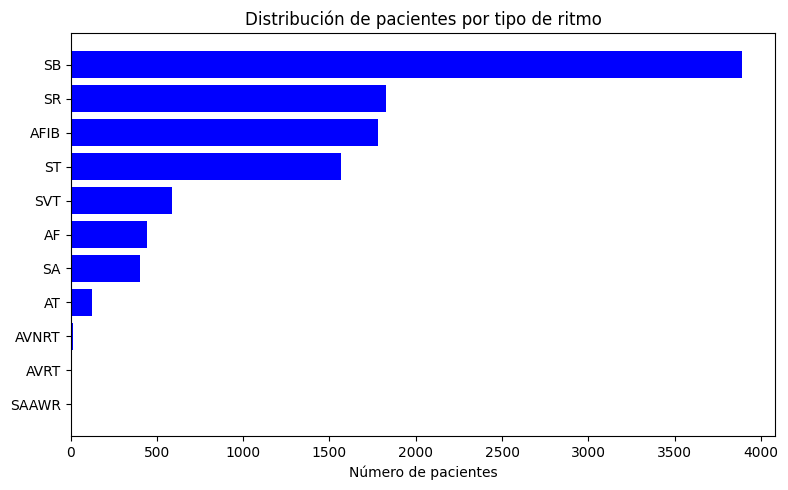

In [16]:
df = pd.read_excel("Diagnostics.xlsx")

print("Total de registros:", df.shape[0])
print(df['Rhythm'].value_counts())
print(df['Gender'].value_counts())
print(df['PatientAge'].describe())

conteo = df['Rhythm'].value_counts().sort_values()
plt.figure(figsize=(8,5))
plt.barh(conteo.index, conteo.values, color= "b")
plt.xlabel("Número de pacientes")
plt.title("Distribución de pacientes por tipo de ritmo")
plt.tight_layout()
plt.show()

**2.** Visualización y caracterización de las señales. Seleccione dos registros de dos tipos tipo de arritmia. Realice una breve consulta de esas dos arritmias y realice una visualización de las señales ECG. Analice los aspectos como la morfología, amplitud, frecuencia cardíaca y regularidad de los latidos.

**Fibrilación Auricular (AFIB):** Es la arritmia sostenida más común en la práctica clínica. Se produce por actividad eléctrica caótica y desorganizada en las aurículas, lo que hace que desaparezca la onda P (se reemplaza por ondulaciones irregulares llamadas "ondas f") y que los intervalos RR sean irregularmente irregulares (no hay un patrón fijo de distancia entre latidos). La frecuencia ventricular puede variar mucho de un latido a otro y de un paciente a otro, dependiendo de cuántos de esos impulsos caóticos logran pasar al ventrículo.

**Taquicardia Sinusal (ST):** Es un ritmo que sigue originándose de forma normal en el nodo sinoauricular (SA) — o sea, mantiene la secuencia eléctrica correcta del corazón: onda P normal antes de cada QRS, con la misma morfología de siempre — pero ocurre a una frecuencia más alta de lo normal, típicamente por encima de 100 lpm (en los datos que tenemos, el promedio es 112 lpm). Es la respuesta normal del corazón ante situaciones como ejercicio, fiebre, ansiedad, dolor, anemia, deshidratación, o algunas condiciones médicas — es decir, muchas veces es una respuesta fisiológica adecuada del cuerpo y no necesariamente indica una enfermedad del corazón en sí.

In [19]:
#Punto 1 - verificar frecuencia de muestreo con más de un archivo de señal
señal_afib = pd.read_csv("MUSE_20180114_135033_25000.csv", header=None)
señal_st   = pd.read_csv("MUSE_20180112_134129_67000.csv", header=None)

duracion_seg = 10  # documentado por el dataset

for nombre, señal in zip(["AFIB", "ST"], [señal_afib, señal_st]):
    num_muestras = señal.shape[0]
    num_canales  = señal.shape[1]
    fs = num_muestras / duracion_seg
    print(f"{nombre}: muestras = {num_muestras}, canales = {num_canales}, fs = {fs} Hz")

AFIB: muestras = 5000, canales = 12, fs = 500.0 Hz
ST: muestras = 5000, canales = 12, fs = 500.0 Hz


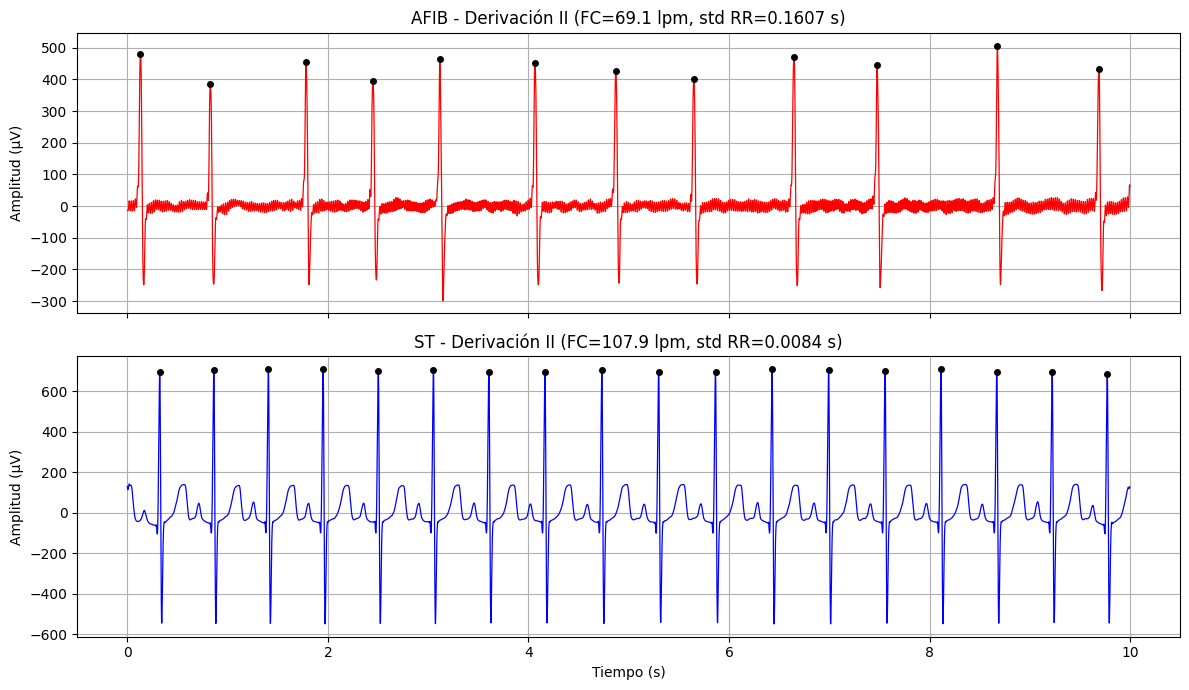

In [17]:

fs = 500

def cargar_señal(ruta_archivo, derivacion=1):
    return pd.read_csv(ruta_archivo, header=None)[derivacion].values

def analizar_ritmo(señal):
    picos, _ = find_peaks(señal, distance=int(fs*0.3), prominence=(señal.max()-señal.min())*0.3)
    rr = np.diff(picos) / fs
    return picos, 60/np.mean(rr), np.std(rr)

def graficar_comparacion(señales, nombres, colores):
    vector_tiempo = np.arange(len(señales[0])) / fs
    fig, axes = plt.subplots(len(señales), 1, figsize=(12,7), sharex=True)
    
    for ax, señal, nombre, color in zip(axes, señales, nombres, colores):
        picos, fc, std_rr = analizar_ritmo(señal)
        ax.plot(vector_tiempo, señal, color, linewidth=0.9)
        ax.plot(vector_tiempo[picos], señal[picos], 'ko', markersize=4)
        ax.set_title(f"{nombre} - Derivación II (FC={fc:.1f} lpm, std RR={std_rr:.4f} s)")
        ax.set_ylabel("Amplitud (µV)")
        ax.grid(True)
    
    axes[-1].set_xlabel("Tiempo (s)")
    plt.tight_layout()
    plt.show()


señal_afib = cargar_señal("MUSE_20180114_135033_25000.csv")
señal_st   = cargar_señal("MUSE_20180112_134129_67000.csv")

graficar_comparacion([señal_afib, señal_st], ["AFIB", "ST"], ["r-", "b-"])